<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

*INTRODUCCION A LA CIENCIA DE DATOS*<br>

DOCENTE:<br>
Mateo Cano Solis<br>

NOMBRES:
1. Santiago Castañeda Garcia
2. Andres Eduardo Medina
3. David Alejandro Montilla Orjuela



Abril 2026


---

# **Análisis Predictivo y Caracterización de la Contratación Estatal en Colombia: Un Enfoque Basado en Datos de SECOP I y II**

## **1. introducción:**
La contratación pública en Colombia representa uno de los pilares más importantes para el desarrollo socioeconómico del país. Con la transición y coexistencia de las plataformas SECOP I y SECOP II, se ha generado un volumen de información sin precedentes sobre cómo el Estado invierte sus recursos. Sin embargo, la complejidad y diversidad de estos datos exigen el uso de herramientas avanzadas de Analítica de Datos para transformar registros administrativos en conocimiento estratégico.

Este proyecto se enfoca en el estudio de los procesos de compra pública que han culminado en contratos efectivos. A través de técnicas de Aprendizaje Automático (Machine Learning), se busca descubrir patrones ocultos en las modalidades de selección, los tiempos de ejecución y la distribución de los presupuestos, permitiendo una visión técnica que aporte a la transparencia y a la eficiencia en la gestión pública

<br><br>

## **2. Objetivos:**

Objetivo General
Desarrollar un modelo de análisis basado en técnicas de aprendizaje automático para caracterizar y predecir métricas clave en los procesos de contratación estatal integrados en las plataformas SECOP I y II.

Objetivos Específicos
Realizar un Análisis Exploratorio de Datos (EDA) para identificar las tendencias de contratación por sectores, regiones y modalidades de selección.

Procesar y estandarizar la información integrada de SECOP I y II, gestionando la limpieza de datos faltantes y la codificación de variables categóricas.

Evaluar diferentes arquitecturas de modelos predictivos mediante el uso de herramientas de AutoML (como AutoGluon), con el fin de determinar el algoritmo que ofrezca mayor precisión en la clasificación o estimación de resultados contractuales.

Interpretar los resultados obtenidos para identificar qué variables (como cuantía, ubicación o tipo de entidad) tienen mayor peso en la configuración de un contrato exitoso.

<br>
VARIABLES OBSERVADAS
<br><br>

|Num|Nombre de la columna|Descripción|Nombre del campo API|Tipo de dato|
|-|-|-|-|-|
|1|Nivel Entidad|Nivel de la entidad publica que desarrolla el proceso de compra, de acuerdo a su cobertura|Nivel entidad|Texto|
|2|Código Entidad SECOP|Código de la entidad en la plataforma SEECOP|Código_entidad_en_secop|Texto |
|3|Nombre de la Entidad|Nombre de la Entidad que desarrolla el proceso de compra pública|nombre_de_la_entidad|Texto |
|4|NIT de la Entidad|	Identificador de la Entidad que desarrolla el proceso de compra pública|nit_de_la_entidad|	Texto|
|5|Departamento Entidad|	Departamento de origen de la Entidad en la plataforma SECOP|	departamento_entidad|	Texto|
|6|Municipio Entidad|	Municipio de origen de la Entidad en la plataforma SECOP|	municipio_entidad|	Texto|
|7|Estado del Proces|	Estado del proceso, de acuerdo con el flujo que se establece y a la modalidad de adquisición bajo la cual se desarrolla|	estado_del_proceso|	Texto|
|8|Modalidad de Contratación|	Modo de adquisición, de acuerdo con las características del proceso y del producto o servicio involucrados|	modalidad_de_contrataci_n|	Texto|
|9|Objeto del contrato|	Descripción detallada del producto o servicio a adquirir, definida al momento de redactar el contrato|	objeto_a_contratar|	Texto|
|10|Objeto del proceso|	Objeto de contratación registrado en la fase de publicación del proceso|	objeto_del_proceso|	Texto|
|11|Tipo de Contrato|	Tipo de contrato que se firma al finalizar el proceso de compra pública|	tipo_de_contrato|	Texto|
|12|Fecha de Firma del Contrato|	Fecha en que se firmó el contrato, sea de forma física o digital|	fecha_de_firma_del_contrato|	Marca de tiempo variable|
|13|Fecha inicio ejecución|	Fecha de Inicio de Ejecución del Contrato|	fecha_inicio_ejecuci_n|	Marca de tiempo variable|
|14|Fecha fin ejecución|	Fecha definida en el contrato como la fecha de finalización de la ejecución|	fecha_fin_ejecuci_n|	Marca de tiempo variable|
|15|ID Contrato|	Identificador en la plataforma del contrato firmado|	numero_del_contrato|	Texto|
|16|ID Proceso|	identificador en la plataforma del proceso desarrollado|	numero_de_proceso|	Texto|
|17|Valor Contrato|	Valor del contrato firmado|	valor_contrato	|numerica|
|18|Núm Raz Social Contratista|Nombre del contratista o de la empresa que proveerá los productos o servicios relacionados en el proceso de compra|num_raz_social_contratista|Texto|
|19|	URL Contrato|	URL del proceso en su correspondiente plataforma.|	url_contrato|	Texto|
|20	|Origen	|Plataforma Origen a donde pertenecen los datos|	origen	|Texto|
|21	|Tipo Documento Proveedor	|Corresponde al tipo de documento del proveedor	|tipo_documento_proveedor|	Texto|
|22|	Documento Proveedor	|Corresponde al número de documento del proveedor|	documento_proveedor	|Texto|






## **3. Carga de Datos:**

In [315]:
#Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy import stats
from sklearn.impute import SimpleImputer
#import scipy.stats as stats
#import statsmodels.api as sm
#import statsmodels.formula.api as smf
#import os
#from scipy.stats import chi2_contingency, pearsonr, kruskal

# Cargar el dataset optimizado
df = pd.read_parquet('datos_secop.parquet')

#visualizar todo el df en pantalla
pd.set_option('display.max_columns', None)

# generar variable para conteo final de Nas
filas_iniciales = len(df)

#numero de columnas y filas
print(f"El dataset tiene: {df.shape[0]} filas y {df.shape[1]} columnas")



El dataset tiene: 300000 filas y 22 columnas


##### *Visualizar el df*

In [316]:
# Mostrar  5 filas aleatorias
df_aleatorio = df.sample(5)
df_aleatorio


,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contrataci_n,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecuci_n,fecha_fin_ejecuci_n,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor
188134,Territorial,701715807,INSTITUCION UNIVERSITARIA DE BARRANQUILLA-IUB,802011065,Atlántico,Barranquilla,Aprobado,Contratación directa,PRESTACIÓN DE SERVICIOS PROFESIONALES EN LA IN...,PRESTACIÓN DE SERVICIOS PROFESIONALES EN LA IN...,Prestación de servicios,2025-11-12T00:00:00.000,NaN,2025-12-31T00:00:00.000,CO1.PCCNTR.8562193,20251226,20400000,VIVIAN CERA DE LOS RIOS,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,22466871
278855,Nacional,702547704,HOSPITAL CENTRAL DE LA POLICIA,830067597,Distrito Capital de Bogotá,Bogotá,En ejecución,Contratación directa,PRESTACION DE SERVICIOS COMO MEDICO GENERAL AS...,PRESTACION DE SERVICIOS COMO MEDICO GENERAL AS...,Prestación de servicios,2025-11-26T00:00:00.000,2025-11-26T00:00:00.000,2026-03-10T00:00:00.000,CO1.PCCNTR.8618445,96-7-201625-25,12395876,LORENA MONSALVE MENDEZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1030588218
266796,Territorial,700787393,ALCALDIA MUNICIPIO DE IBAGUE*,800113389,Tolima,Ibagué,Modificado,Contratación directa,GOB461: PRESTACIÒN DE SERVICIOS PROFESIONALES ...,GOB461: PRESTACIÒN DE SERVICIOS PROFESIONALES ...,Prestación de servicios,2025-11-21T00:00:00.000,2025-11-22T00:00:00.000,2025-12-31T00:00:00.000,CO1.PCCNTR.8617637,3189 DEL 20 DE NOVIEMBRE DEL 2025,4800000,DIEGO MAURICIO GALEANO ORDOÑEZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,79535684
283653,Territorial,702769076,SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO O...,900959051,Distrito Capital de Bogotá,No Definido,Modificado,Contratación régimen especial,PRESTAR SERVICIOS DE APOYO A LA GESTIÓN COMO T...,PRESTAR SERVICIOS DE APOYO A LA GESTIÓN COMO T...,Prestación de servicios,2025-09-30T00:00:00.000,2025-10-01T00:00:00.000,2025-12-15T00:00:00.000,CO1.PCCNTR.8373592,PS 6626 2025,8234000,Briyith Daniela Sánchez Sierra,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1031179699
224680,Nacional,701715401,UNIDAD ADMINISTRATIVA ESPECIAL JUNTA CENTRAL D...,900180739,Distrito Capital de Bogotá,No Definido,Cerrado,Contratación directa,Prestar los servicios profesionales para lleva...,Prestar los servicios profesionales para lleva...,Prestación de servicios,2024-03-04T00:00:00.000,2024-03-05T00:00:00.000,2024-09-04T00:00:00.000,CO1.PCCNTR.6043890,174-UAE-JCC-CD-PS-2024,21600000,Jessica Nathaly Lopez Zarabanda,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,53032158


OBSERVACION: 
1. Existe en la columna (estado_del_proceso) contratos que estan en estado borrador. lo que significa  que aun no están publicados oficialmente o no ha sido adjudicado o está en proceso de elaboración o revisión, por lo que carece de mucha de informacion en otras columnas, estas filas con este valor son candidatas a eliminar

2. Se debe realizar un tratamiento de datos que permita, cambiar los nombres de las columnas, pasar los datos a minúsculas, quitar tildes, convertir datos de tipo object a Date.

3. Se deben eliminar los contratos que tienen un valor de contrato en $ 0 pesos.


## **4. Tratamiento preliminar de datos**

In [317]:
#Esto nos deja solo con contratos que ya pasaron la etapa de creación inicial
df = df[df['estado_del_proceso'] != 'Borrador'].copy()
#Esto elimina los contratos que tienen valor $0
df = df[df['valor_contrato'] != 0].copy()

# Obtener un resumen de la estructura del conjunto de datos:

print("\n*****TABLA CON TIPO DE VARIABLE, VALORES UNICOS Y VALORES FALTANTES*****\n")
def generar_diccionario(Data):
    dicc = []
    for col in Data.columns:
        dicc.append({
            "Variable": col,
            "Tipo pandas": Data[col].dtype,
            "Cantidad de valores únicos": Data[col].nunique(),
            "Valores faltantes": Data[col].isna().sum()
        })
    return pd.DataFrame(dicc)

generar_diccionario(df)


*****TABLA CON TIPO DE VARIABLE, VALORES UNICOS Y VALORES FALTANTES*****



,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,str,7,0
1,codigo_entidad_en_secop,str,4720,0
2,nombre_de_la_entidad,str,4819,0
3,nit_de_la_entidad,str,3896,0
4,departamento_entidad,str,37,0
5,municipio_entidad,str,1075,0
6,estado_del_proceso,str,18,0
7,modalidad_de_contrataci_n,str,30,0
8,objeto_a_contratar,str,159989,0
9,objeto_del_proceso,str,166975,1


##### *Cambiar nombres de columnas*

In [318]:
df.rename(columns={'modalidad_de_contrataci_n': 'modalidad_de_contratacion', 'fecha_inicio_ejecuci_n': 'fecha_inicio_ejecucion',
                   'fecha_fin_ejecuci_n': 'fecha_fin_ejecucion'},
          inplace=True)

##### *Cambiar tipo de dato 'Object' a 'Datetime'*

In [319]:
columnas_fechas = ['fecha_de_firma_del_contrato','fecha_inicio_ejecucion', 'fecha_fin_ejecucion']

for col in columnas_fechas:
    df[col] = pd.to_datetime(df[col])

In [320]:
df['fecha_inicio_ejecucion']

0        2015-11-17
1        2015-11-17
2        2015-11-17
3        2015-11-17
4        2016-04-04
            ...    
299995   2025-10-06
299996   2025-07-17
299997   2025-07-18
299998   2025-10-02
299999   2025-11-28
Name: fecha_inicio_ejecucion, Length: 259823, dtype: datetime64[us]

##### *Cambiar datos del dataset tipo dtype = 'str' a Minúsculas*

In [321]:
columnas_texto = ['documento_proveedor','nivel_entidad', 'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', 'estado_del_proceso', 'modalidad_de_contratacion', 'objeto_a_contratar', 'objeto_del_proceso', 'tipo_de_contrato', 'numero_de_proceso', 'nom_raz_social_contratista', 'origen', 'tipo_documento_proveedor',   ]
for col in columnas_texto       :
        df[col] = df[col].str.lower().str.strip()

##### *Cambiar datos del dataset tipo dtype = 'str' sin tíldes para facilidad en la búsqueda*

In [322]:
mapeo_tildes = {
    'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u',
    'Á': 'A', 'É': 'E', 'Í': 'I', 'Ó': 'O', 'Ú': 'U',
    'ü': 'u', 'Ü': 'U'
}

for col in df.columns:
    # Solo actuamos si la columna es de tipo texto (str)
    if df[col].dtype == 'str':
        # Aplicamos los reemplazos del diccionario
        for tildada, limpia in mapeo_tildes.items():
            df[col] = df[col].str.replace(tildada, limpia, regex=False)

##### *Resumen de valores nulos*

In [323]:
resumen = pd.DataFrame({
    'Nulos (NaN)': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Espacios Vacíos': df.apply(lambda x: (x == " ").sum()),
    'Tipo de Dato': df.dtypes
}).sort_values('Porcentaje (%)', ascending=False)
print(resumen[(resumen['Nulos (NaN)'] > 0) | (resumen['Espacios Vacíos'] > 0)])

                             Nulos (NaN)  Porcentaje (%)  Espacios Vacíos  \
fecha_inicio_ejecucion             64649           24.88                0   
fecha_de_firma_del_contrato        22673            8.73                0   
fecha_fin_ejecucion                17859            6.87                0   
objeto_del_proceso                     1            0.00                0   
numero_de_proceso                      1            0.00                0   
nom_raz_social_contratista             2            0.00                0   
documento_proveedor                    4            0.00                0   

                               Tipo de Dato  
fecha_inicio_ejecucion       datetime64[us]  
fecha_de_firma_del_contrato  datetime64[us]  
fecha_fin_ejecucion          datetime64[us]  
objeto_del_proceso                      str  
numero_de_proceso                       str  
nom_raz_social_contratista              str  
documento_proveedor                     str  



===  GRÁFICO DE PORCENTAJES DE NAS POR COLUMNA ===


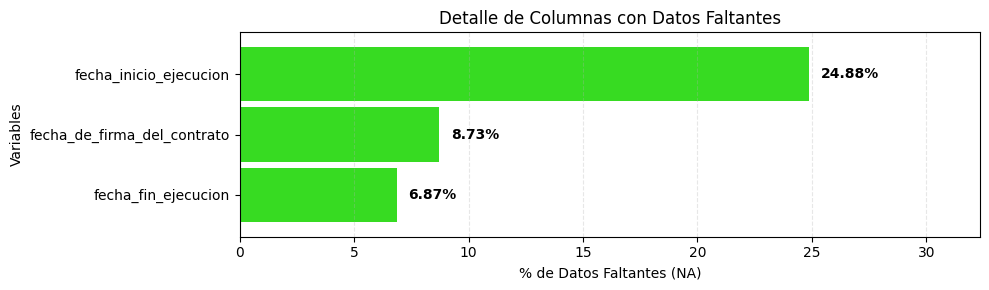

In [324]:
# CALCULAR PORCENTAJE DE FALTANTES
print("\n===  GRÁFICO DE PORCENTAJES DE NAS POR COLUMNA ===")
faltantes = df.isna().mean().mul(100).sort_values(ascending=False).round(2)

# FILTRO: Solo columnas con más de 0% de nulos
faltantes_reales = faltantes[faltantes > 0.0]

if not faltantes_reales.empty:
    # Ajuste dinámico de altura: 0.6 pulgadas por cada barra encontrada
    dinamic_h = max(3, len(faltantes_reales) * 0.6)

    plt.figure(figsize=(10, dinamic_h))

    # Graficamos con un color profesional
    ax = faltantes_reales.plot(kind="barh", color="#37db22", width=0.9)

    ax.set_xlabel("% de Datos Faltantes (NA)")
    ax.set_ylabel("Variables")
    ax.set_title("Detalle de Columnas con Datos Faltantes")
    ax.invert_yaxis()

    # AJUSTE DE ESCALA:
    # Usamos un margen basado en el valor máximo para que las etiquetas no se corten
    max_val = faltantes_reales.max()
    plt.xlim(0, max_val * 1.3 if max_val > 0 else 10)

    # Añadir etiquetas de valor
    for i, v in enumerate(faltantes_reales):
        # El texto se posiciona un poco a la derecha del final de la barra
        ax.text(v + (max_val * 0.02 if max_val > 0 else 0.1), i, f"{v}%",
                color='black', va='center', fontweight='bold')

    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


##### *Mapa valores faltantes*

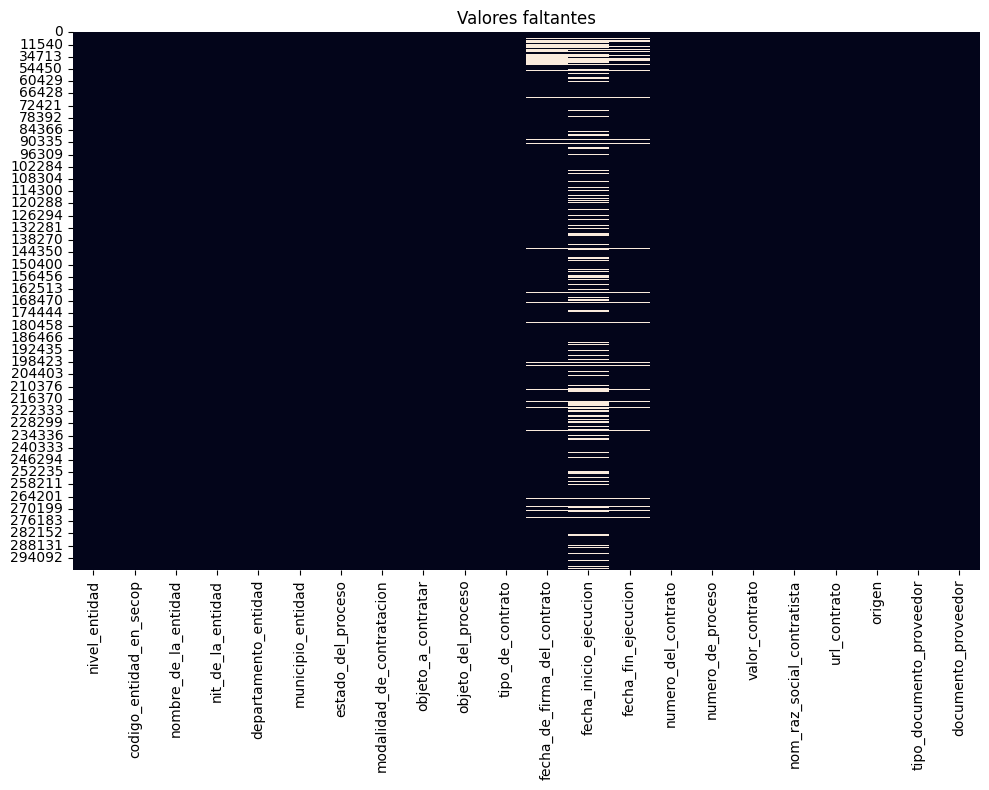

In [325]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.isna(), cbar=False)
plt.title("Valores faltantes")
plt.tight_layout()
plt.show()

##### *Imputacion de datos con los valores de la fecha de la firma del contrato, para llenar datos de la fecha de inicio, que muchas veces suele ser la misma del inicio, luego usando la moda para llenar los valores NAN de las fechas que en ambas columnas son vacias*

In [ ]:
# 1. Cruce entre columnas

#Llenar los vacíos de la fecha de inicio con los valores de la firma del contrato
df['fecha_inicio_ejecucion'] = df['fecha_inicio_ejecucion'].combine_first(df['fecha_de_firma_del_contrato'])
#funciona a la inversa para llenar los datos
df['fecha_de_firma_del_contrato'] = df['fecha_de_firma_del_contrato'].combine_first(df['fecha_inicio_ejecucion'])

# 2. Usamos la moda aquí como ejemplo por ser lo más frecuente
moda_fecha = df['fecha_inicio_ejecucion'].mode()[0]

df['fecha_inicio_ejecucion'] = df['fecha_inicio_ejecucion'].fillna(moda_fecha)
df['fecha_de_firma_del_contrato'] = df['fecha_de_firma_del_contrato'].fillna(moda_fecha)

#3. Imputación por "Moda" de duración por categoría de la columna como tipo_de_contrato.
df['duracion_dias'] = (df['fecha_fin_ejecucion'] - df['fecha_inicio_ejecucion']).dt.days

# Calculamos la media de días por tipo de contrato
media_por_tipo = df.groupby('tipo_de_contrato')['duracion_dias'].transform('mean')

# Llenamos los vacíos: Inicio + (media de días del tipo de contrato)
mask = df['fecha_fin_ejecucion'].isna()
df.loc[mask, 'fecha_fin_ejecucion'] = df.loc[mask, 'fecha_inicio_ejecucion'] + pd.to_timedelta(media_por_tipo[mask], unit='D')

 #df['fecha_fin_ejecucion'] = pd.to_datetime(df['fecha_fin_ejecucion']).dt.date


In [ ]:
df.loc[531]

In [331]:
df.head(5)

,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecucion,fecha_fin_ejecucion,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor
0,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4416408,224-2015 contrato de prestacion de servicio,1500000,anderson antonio urbano ruales,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,18130744
1,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418304,227-2015 contrato de prestacion de servicio,1500000,juan sebastian buitrago,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,1094885358
2,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418312,230-2015 contrato de prestacion de servicio,1400000,julian mauricio ocampo,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,4375686
3,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418338,234-2015 contrato de prestacion de servicio,1500000,juan pablo castaneda daza,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,1.097.390.531
4,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2016-04-04,2016-04-04,2016-08-04,16-12-4954064,contrato de prestacion de servicios 045 de 2016,4200000,erick alberto gamro vega,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,7603987


In [328]:
df.info()

<class 'pandas.DataFrame'>
Index: 259823 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   nivel_entidad                259823 non-null  str           
 1   codigo_entidad_en_secop      259823 non-null  str           
 2   nombre_de_la_entidad         259823 non-null  str           
 3   nit_de_la_entidad            259823 non-null  str           
 4   departamento_entidad         259823 non-null  str           
 5   municipio_entidad            259823 non-null  str           
 6   estado_del_proceso           259823 non-null  str           
 7   modalidad_de_contratacion    259823 non-null  str           
 8   objeto_a_contratar           259823 non-null  str           
 9   objeto_del_proceso           259822 non-null  str           
 10  tipo_de_contrato             259823 non-null  str           
 11  fecha_de_firma_del_contrato  259823 non-nu

In [329]:
#comprobamos cuantas filas quedan
df.shape[0]

259823

OBSERVACION: El dataset nos quedo con 272015 lo cual nos dice que exisitian cerca de 28000 contratos que a la fecha no se han aprobado y otros que tenian valor de contrato en $0 pesos, estos podriamos tomarlos para probar el modelo si a la fecha de terminacion de este proyecto ya tienen aprobacion. existen  7528  filas que no tienen fecha de inicio de ejecucion, esto puede ser que aun no se ha terminado el contrato por lo que se debe comprobar que tampoco debe tener fecha de de fin de ejecucion. 

#debemos tenr metricas de calsificacion y variar el treshold